# Weather Data

From 1988 until the present, my father has kept records of precipitation and high/low temperatures of our hometown of Oskaloosa, Iowa. Throughout this notebook we will look at:
- rolling averages
- warming and cooling period trends
- parametric modeling

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [3]:
os.getcwd()

'/Users/smittyboop/Desktop/weather_data/weather_data'

In [4]:
data = pd.read_csv(r"/Users/smittyboop/Desktop/weather_data/weather_data/data/weather_data.csv")
data.head()

,date,high_temp,low_temp,precipitation (in inches)
0,01/01/1988,NaN,NaN,0.0
1,01/02/1988,NaN,NaN,0.0
2,01/03/1988,NaN,NaN,0.0
3,01/04/1988,NaN,NaN,0.0
4,01/05/1988,NaN,NaN,0.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13149 entries, 0 to 13148
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       13149 non-null  object 
 1   high_temp                  12955 non-null  float64
 2   low_temp                   10612 non-null  float64
 3   precipitation (in inches)  12997 non-null  float64
dtypes: float64(3), object(1)
memory usage: 411.0+ KB


In [6]:
data.index = pd.to_datetime(data.date)
data.drop(labels=['date'], axis=1, inplace=True)

In [7]:
data.head()

,high_temp,low_temp,precipitation (in inches)
date,,,
1988-01-01,NaN,NaN,0.0
1988-01-02,NaN,NaN,0.0
1988-01-03,NaN,NaN,0.0
1988-01-04,NaN,NaN,0.0
1988-01-05,NaN,NaN,0.0


In [8]:
data.isna().sum()/data.shape[0]

high_temp                    0.014754
low_temp                     0.192942
precipitation (in inches)    0.011560
dtype: float64

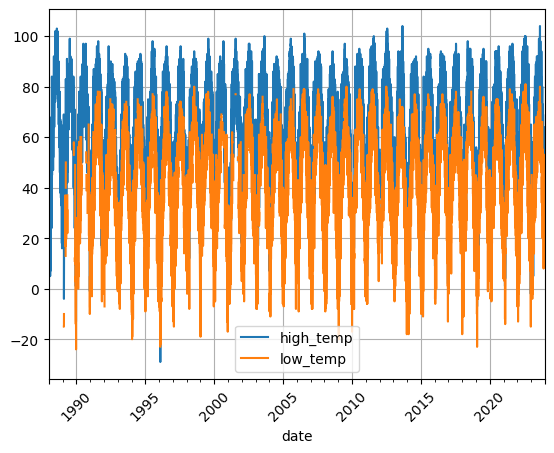

In [9]:
data[['high_temp', 'low_temp']].plot(kind='line', grid=True)
plt.xticks(rotation=45)
plt.show()

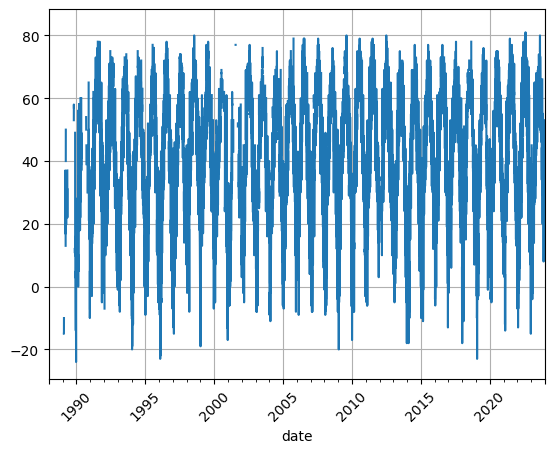

In [10]:
data['low_temp'].plot(kind='line', grid=True)
plt.xticks(rotation=45)
plt.show()

In [11]:
# 1992 onward

data_1992 = data.loc['01/01/1992':]
data_1992.head()

,high_temp,low_temp,precipitation (in inches)
date,,,
1992-01-01,32.0,29.0,0.0
1992-01-02,35.0,31.0,0.2
1992-01-03,38.0,31.0,0.0
1992-01-04,32.0,28.0,0.0
1992-01-05,34.0,30.0,0.2


In [12]:
data_1992.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11688 entries, 1992-01-01 to 2023-12-31
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   high_temp                  11612 non-null  float64
 1   low_temp                   10148 non-null  float64
 2   precipitation (in inches)  11626 non-null  float64
dtypes: float64(3)
memory usage: 365.2 KB


In [13]:
data_1992.isna().sum()/data_1992.shape[0]

high_temp                    0.006502
low_temp                     0.131759
precipitation (in inches)    0.005305
dtype: float64

In [14]:
for col in data_1992.columns:
    data_1992[col] = data_1992[col].fillna(data_1992[col].median())

/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_87839/2543109567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_1992[col] = data_1992[col].fillna(data_1992[col].median())
/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_87839/2543109567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_1992[col] = data_1992[col].fillna(data_1992[col].median())
/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_87839/2543109567.py:2: SettingWithCopyWarning: 
A value is trying to 

In [15]:
data_1992.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11688 entries, 1992-01-01 to 2023-12-31
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   high_temp                  11688 non-null  float64
 1   low_temp                   11688 non-null  float64
 2   precipitation (in inches)  11688 non-null  float64
dtypes: float64(3)
memory usage: 365.2 KB


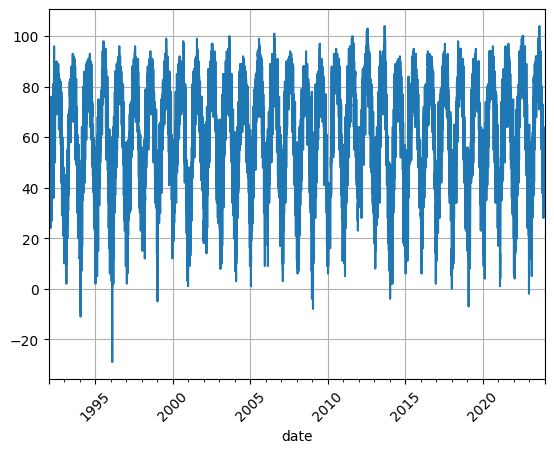

In [16]:
data_1992['high_temp'].plot(kind='line', grid=True)
plt.xticks(rotation=45)
plt.show()

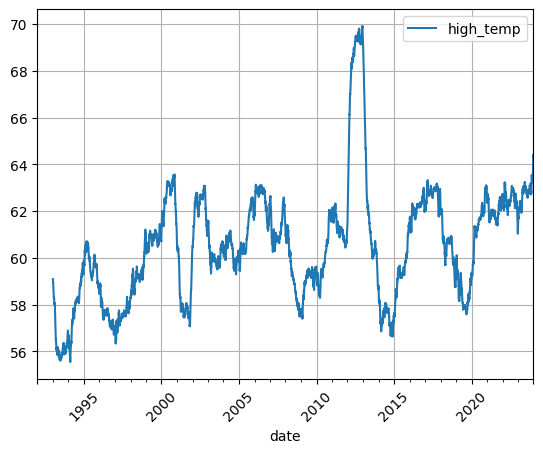

In [17]:
data_1992[["high_temp"]].rolling(365).mean().plot(kind='line', grid=True)
plt.xticks(rotation=45)
plt.show()

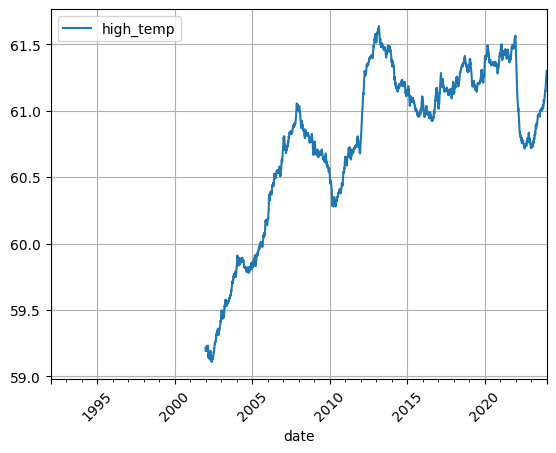

In [18]:
data_1992[["high_temp"]].rolling(3650).mean().plot(kind='line', grid=True)
plt.xticks(rotation=45)
plt.show()

In [19]:
yearly_averages = data_1992.rolling(365).mean()
decadal_averages = data_1992.rolling(3650).mean()

In [20]:
data = pd.concat([data_1992, yearly_averages, decadal_averages], axis=1)

In [21]:
new_columns = ["high_temp", "low_temp", "precipitation (in inches)", \
               "high_temp_yearly_averages", "low_temp_yearly_averages", "precipitation_yearly_averages", \
                "high_temp_decadal_averages", "low_temp_decadal_averages", "precipitation_decadal_averages"]

In [22]:
data.columns = new_columns

In [23]:
data.head()

,high_temp,low_temp,precipitation (in inches),high_temp_yearly_averages,low_temp_yearly_averages,precipitation_yearly_averages,high_temp_decadal_averages,low_temp_decadal_averages,precipitation_decadal_averages
date,,,,,,,,,
1992-01-01,32.0,29.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-02,35.0,31.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-03,38.0,31.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-04,32.0,28.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1992-01-05,34.0,30.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN


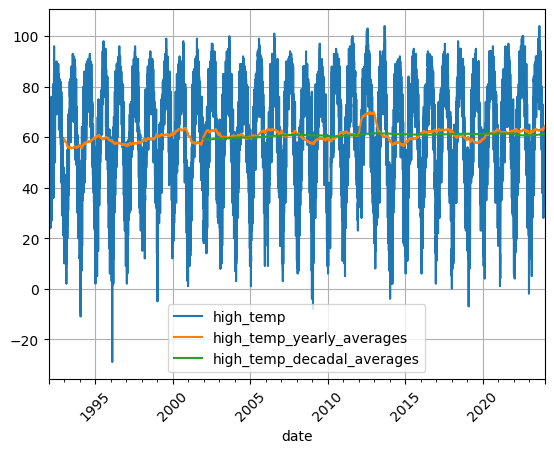

In [24]:
data[['high_temp', "high_temp_yearly_averages", "high_temp_decadal_averages"]].plot(kind="line", grid=True)
# plt.hlines(y=data.high_temp.mean(), xmin="01/01/1992", xmax="12/31/2023", color="red", label="Average")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [25]:
data['high_temp_yearly_averages'].std()

np.float64(2.447106406978527)

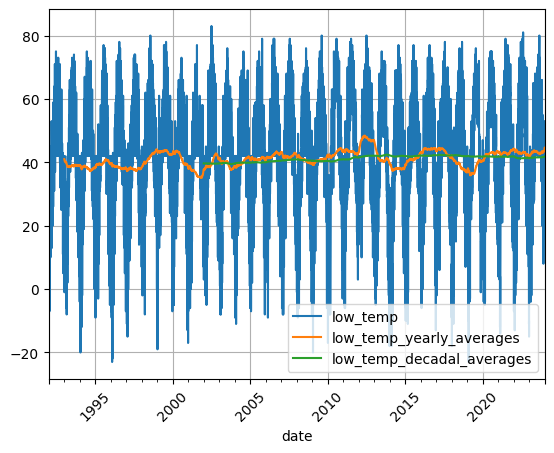

In [26]:
data[['low_temp', "low_temp_yearly_averages", "low_temp_decadal_averages"]].plot(kind="line", grid=True)
plt.xticks(rotation=45)
plt.show()

In [27]:
data["low_temp_yearly_averages"].std()

np.float64(2.436880704370802)

## Warming Months vs Cooling Months

In [34]:
spring = data[data.index.month.isin([3,4,5])]
autumn = data[data.index.month.isin([9,10,11])]

In [45]:
spring.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2944 entries, 1992-03-01 to 2023-05-31
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   high_temp                       2944 non-null   float64
 1   low_temp                        2944 non-null   float64
 2   precipitation (in inches)       2944 non-null   float64
 3   high_temp_yearly_averages       2852 non-null   float64
 4   low_temp_yearly_averages        2852 non-null   float64
 5   precipitation_yearly_averages   2852 non-null   float64
 6   high_temp_decadal_averages      2024 non-null   float64
 7   low_temp_decadal_averages       2024 non-null   float64
 8   precipitation_decadal_averages  2024 non-null   float64
dtypes: float64(9)
memory usage: 230.0 KB


In [46]:
autumn.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2912 entries, 1992-09-01 to 2023-11-30
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   high_temp                       2912 non-null   float64
 1   low_temp                        2912 non-null   float64
 2   precipitation (in inches)       2912 non-null   float64
 3   high_temp_yearly_averages       2821 non-null   float64
 4   low_temp_yearly_averages        2821 non-null   float64
 5   precipitation_yearly_averages   2821 non-null   float64
 6   high_temp_decadal_averages      2002 non-null   float64
 7   low_temp_decadal_averages       2002 non-null   float64
 8   precipitation_decadal_averages  2002 non-null   float64
dtypes: float64(9)
memory usage: 227.5 KB


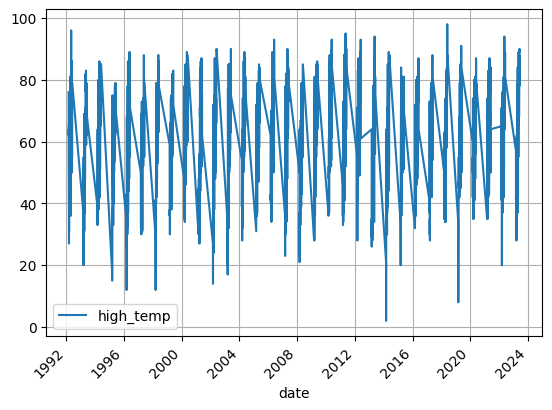

In [37]:
spring[['high_temp',
        # 'high_temp_yearly_averages',
        # "high_temp_decadal_averages"
        ]].plot(kind="line", grid=True)
plt.xticks(rotation=45)
plt.show()

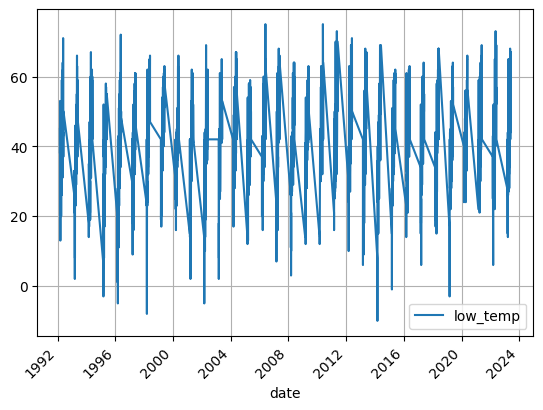

In [42]:
spring[['low_temp',
        # 'low_temp_yearly_averages',
        # "low_temp_decadal_averages"
        ]].plot(kind="line", grid=True)
plt.xticks(rotation=45)
plt.show()

In [40]:
spring[["high_temp", "low_temp"]].var(), spring[["high_temp", "low_temp"]].std()

(high_temp    237.279683
 low_temp     159.589716
 dtype: float64,
 high_temp    15.403885
 low_temp     12.632882
 dtype: float64)

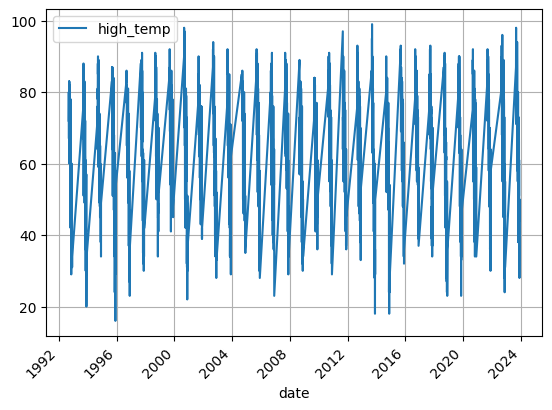

In [44]:
autumn[['high_temp',
        # 'high_temp_yearly_averages',
        # "high_temp_decadal_averages"
        ]].plot(kind="line", grid=True)
plt.xticks(rotation=45)
plt.show()

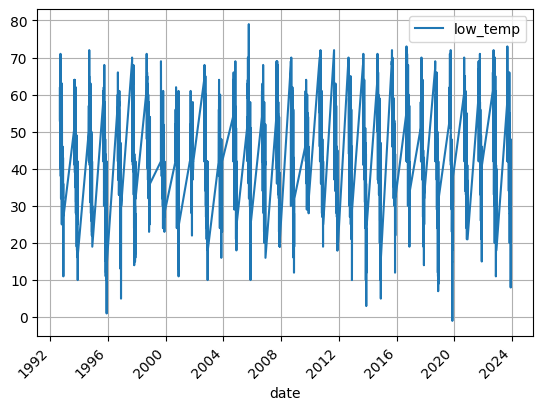

In [43]:
autumn[['low_temp',
        # 'low_temp_yearly_averages',
        # "low_temp_decadal_averages"
        ]].plot(kind="line", grid=True)
plt.xticks(rotation=45)
plt.show()

In [41]:
autumn[["high_temp", "low_temp"]].var(), autumn[["high_temp", "low_temp"]].std()

(high_temp    249.971989
 low_temp     158.648179
 dtype: float64,
 high_temp    15.810502
 low_temp     12.595562
 dtype: float64)

## Parametric Modeling

In [48]:
data_2008 = data.loc['2008-01-01':'2008-12-31']
data_2008.head()

,high_temp,low_temp,precipitation (in inches),high_temp_yearly_averages,low_temp_yearly_averages,precipitation_yearly_averages,high_temp_decadal_averages,low_temp_decadal_averages,precipitation_decadal_averages
date,,,,,,,,,
2008-01-01,19.0,10.0,0.0,61.120548,41.934247,0.155342,61.004384,40.915342,0.111263
2008-01-02,11.0,-1.0,0.0,61.038356,41.868493,0.155342,60.997808,40.907945,0.111153
2008-01-03,31.0,2.0,0.0,60.980822,41.786301,0.155342,60.996438,40.899726,0.111126
2008-01-04,37.0,32.0,0.0,60.934247,41.756164,0.155342,60.996438,40.900000,0.111126
2008-01-05,45.0,34.0,0.0,60.931507,41.753425,0.155342,60.999726,40.901644,0.111126


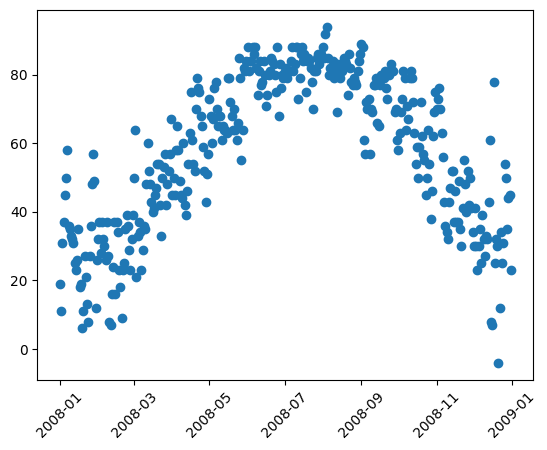

In [55]:
plt.scatter(x=data_2008.index, y=data_2008.high_temp)
plt.xticks(rotation=45)
plt.show()

In [56]:
data_08_09 = data.loc['2008-01-01':'2009-12-31']
data_08_09.head()

,high_temp,low_temp,precipitation (in inches),high_temp_yearly_averages,low_temp_yearly_averages,precipitation_yearly_averages,high_temp_decadal_averages,low_temp_decadal_averages,precipitation_decadal_averages
date,,,,,,,,,
2008-01-01,19.0,10.0,0.0,61.120548,41.934247,0.155342,61.004384,40.915342,0.111263
2008-01-02,11.0,-1.0,0.0,61.038356,41.868493,0.155342,60.997808,40.907945,0.111153
2008-01-03,31.0,2.0,0.0,60.980822,41.786301,0.155342,60.996438,40.899726,0.111126
2008-01-04,37.0,32.0,0.0,60.934247,41.756164,0.155342,60.996438,40.900000,0.111126
2008-01-05,45.0,34.0,0.0,60.931507,41.753425,0.155342,60.999726,40.901644,0.111126


In [85]:
xs = np.linspace(0, len(data_08_09))
cos = [-np.cos(np.pi*x) + 52 for x in xs]

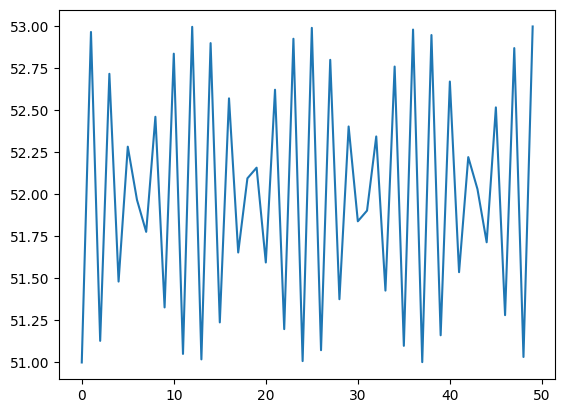

In [86]:
plt.plot(cos)

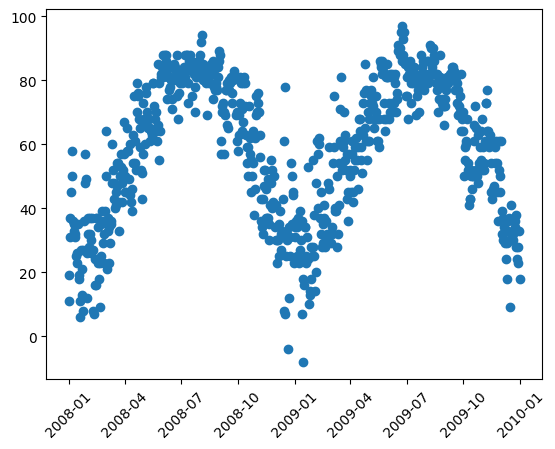

In [ ]:
plt.scatter(x=data_08_09.index, y=data_08_09.high_temp)
plt.xticks(rotation=45)
plt.show()